In [1]:
import pandas as pd
import os
import re
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
import numpy as np
from sklearn import preprocessing

In [2]:
wetlab_analysis_dir = '/data/bbg/projects/prominent/analysis/wetlab_analysis/data'
plotsdir = f"{wetlab_analysis_dir}/plots"

In [3]:
data = pd.read_table("/data/bbg/projects/prominent/analysis/wetlab_analysis/data/output_data/2025-12-23.WetDryMetrics.tsv")

In [4]:
metadata = pd.read_csv(f"./scratch/cord_bloods.csv")
metadata["tech_buffer"] = metadata["tech"] + "_" + metadata["buffer"]
metadata

,sample,tech,buffer,tech_buffer
0,SC001_B1_1_H_1,TWS,TWS,TWS_TWS
1,SC001_B1_1_H_2,cfDNA,Ultrashear,cfDNA_Ultrashear
2,SC001_B1_2_H_1,MNE,Ultrashear,MNE_Ultrashear
3,SC001_B1_2_H_2,MNE,r11,MNE_r11
4,SC002_B1_1_H_1,TWS,TWS,TWS_TWS
5,SC002_B1_1_H_2,cfDNA,Ultrashear,cfDNA_Ultrashear
6,SC003_B1_1_H_1,TWS,TWS,TWS_TWS
7,SC003_B1_1_H_2,cfDNA,Ultrashear,cfDNA_Ultrashear
8,SC003_B1_2_H_1,MNE,Ultrashear,MNE_Ultrashear
9,SC003_B1_2_H_2,MNE,r11,MNE_r11


In [5]:
cord_blood_data = data[data["TISSUE"] == 'CordBlood']
cord_blood_data = cord_blood_data[cord_blood_data["SAMPLE_ID"].str.startswith("SC0")]
cord_blood_data = metadata.merge(cord_blood_data, right_on="SAMPLE_ID", left_on="sample", how="left")
cord_blood_data

,sample,tech,buffer,tech_buffer,PROJECT,Sample ID,IRB_subsample_id,WetLab>>Sample type,WetLab>>Panel,WetLab>>Panel Size (Kb),...,Combined>>unique_molecules_obs/exp6,Combined>>recovery.input_ng2duplex_depth,Combined>>recovery.lig_ng2duplex_depth,Combined>>recovery.qpcr_ng2duplex_depth,Novogene>>Sample_barcode,Novogene>>Project_ID,Novogene>>GBs_obtained,Novogene>>GBs_requested,SeqInfo>>GBs_not_analysed,Combined>>GBs_requested/optimal
0,SC001_B1_1_H_1,TWS,TWS,TWS_TWS,TWS041,TWS041_01,SC001_B1_1_H_1,Cord-Blood,Pancancer,800.0,...,1.339685,0.035802,0.128299,0.938344,TWS041_01,NOVOGENE_54,240.59,250.0,-0.004408,1.457505
1,SC001_B1_1_H_2,cfDNA,Ultrashear,cfDNA_Ultrashear,IDT009,IDT009_01,SC001_B1_1_H_2,Cord blood,Pancancer,800.0,...,2.510347,0.017029,0.108521,0.677269,IDT009_01,NOVOGENE_54,125.64,124.0,-0.004709,0.988874
2,SC001_B1_2_H_1,MNE,Ultrashear,MNE_Ultrashear,MNE038,MNE038_01,SC001_B1_2_H_1,Cord blood,Pancancer,800.0,...,0.704241,0.034188,0.171513,0.680130,MNE038_01,NOVOGENE_78,1176.43,1000.0,-0.000771,1.878685
3,SC001_B1_2_H_2,MNE,r11,MNE_r11,MNE038,MNE038_02,SC001_B1_2_H_2,Cord blood,Pancancer,800.0,...,1.424898,0.025167,0.142178,0.922712,MNE038_02,NOVOGENE_78,416.09,405.0,-0.003556,1.093840
4,SC002_B1_1_H_1,TWS,TWS,TWS_TWS,TWS041,TWS041_02,SC002_B1_1_H_1,Cord-Blood,Pancancer,800.0,...,1.376858,0.044852,0.117973,0.901511,TWS041_02,NOVOGENE_54,296.98,302.0,0.004780,1.417158
5,SC002_B1_1_H_2,cfDNA,Ultrashear,cfDNA_Ultrashear,IDT009,IDT009_02,SC002_B1_1_H_2,Cord blood,Pancancer,800.0,...,2.891202,0.022048,0.116461,0.842152,IDT009_02,NOVOGENE_54,164.71,160.0,0.003506,1.016367
6,SC003_B1_1_H_1,TWS,TWS,TWS_TWS,TWS041,TWS041_03,SC003_B1_1_H_1,Cord-Blood,Pancancer,800.0,...,1.601622,0.046155,0.128939,1.056854,TWS041_03,NOVOGENE_54,257.55,274.0,-0.001613,1.204521
7,SC003_B1_1_H_2,cfDNA,Ultrashear,cfDNA_Ultrashear,IDT009,IDT009_03,SC003_B1_1_H_2,Cord blood,Pancancer,800.0,...,2.268342,0.030310,0.140061,0.787056,IDT009_03,NOVOGENE_54,223.24,226.0,0.009243,1.095304
8,SC003_B1_2_H_1,MNE,Ultrashear,MNE_Ultrashear,MNE038,MNE038_03,SC003_B1_2_H_1,Cord blood,Pancancer,800.0,...,0.884272,0.030650,0.083555,0.480844,MNE038_03,NOVOGENE_78,886.01,845.0,0.005314,1.553671
9,SC003_B1_2_H_2,MNE,r11,MNE_r11,MNE038,MNE038_04,SC003_B1_2_H_2,Cord blood,Pancancer,800.0,...,1.178021,0.037691,0.154519,0.798068,MNE038_04,NOVOGENE_78,832.43,750.0,0.008495,1.351719


In [6]:
cord_blood_data["OptimalReadXDuplexRead"] = (cord_blood_data['FamMetrics>>total_GBs_for_optimal']/300*1e9) / cord_blood_data['FamMetrics>>all.duplex.dscs']

<Axes: >

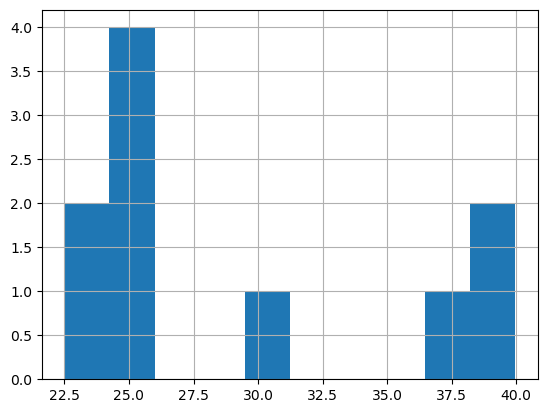

In [8]:
cord_blood_data["OptimalReadXDuplexRead"].hist()

In [9]:
columns_to_plot = [
    #    'WetLab>>Input (ng)', 'WetLab>>Real diversity --> fmol to PCR1',
    #    'WetLab>>Recovery_Input2Lig_raw', 'WetLab>>Recovery_Input2Lig_genomic',
    #    'WetLab>>Recovery_Input2Lig_qpcr', 'WetLab>>qPCR unique molecules',
    #    'WetLab>>qpcr_unique_molecules_6', 'WetLab>>Theoretical_max_depth-lig',
    #    'WetLab>>Theoretical_max_depth-lib',
       'SeqInfo>>GBs_obtained',
       'FamMetrics>>total_GBs_for_optimal', 'SeqInfo>>GBs_missing',
       'BamQC>>duplex.median_insert_size', 'BamQC>>duplex.mean_coverage',
       'Combined>>unique_molecules_obs/exp6',
       'Combined>>recovery.input_ng2duplex_depth',
    #    'Combined>>recovery.lig_ng2duplex_depth',
    #    'Combined>>recovery.qpcr_ng2duplex_depth',
       'FamMetrics>>on_target.unique_molecules_perc',
    #    'FamMetrics>>on_target.unique_molecules',
       'FamMetrics>>on_target.duplicates',
    #    'FamMetrics>>all.duplicates',
       'FamMetrics>>on_target.duplex.peak_size',
       'FamMetrics>>on_target.duplex.sscs_x_dscs',
       'FamMetrics>>amplification_bias.on/off',
    #    'Novogene>>Project_ID',
    #    'Novogene>>GBs_requested', 'Novogene>>GBs_obtained',
    #    'SeqInfo>>GBs_not_analysed', 'Combined>>GBs_requested/optimal',
    "OptimalReadXDuplexRead"
       ]

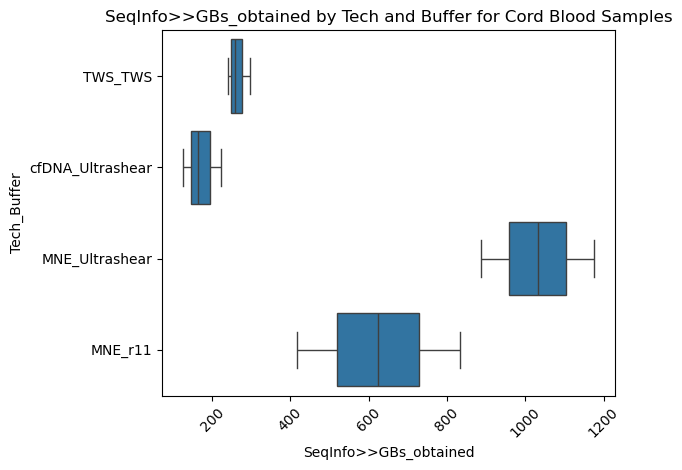

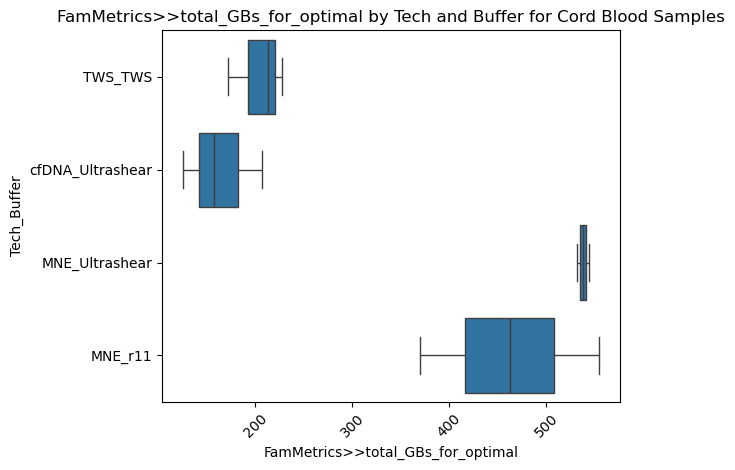

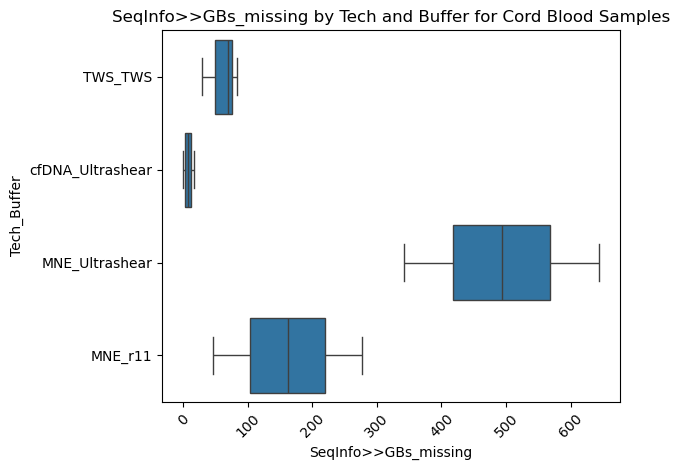

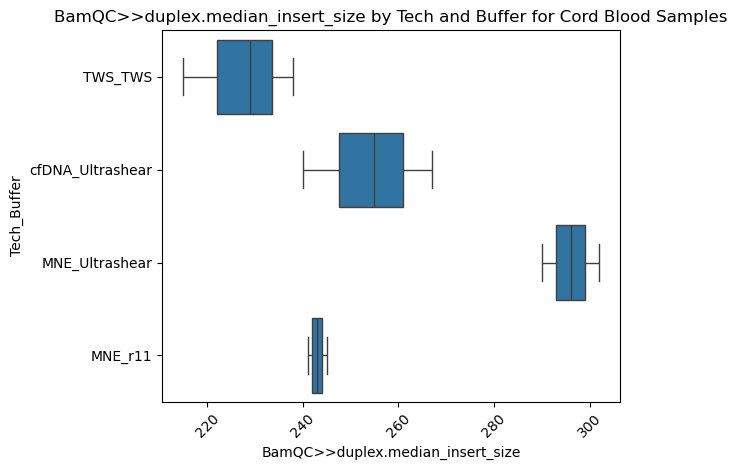

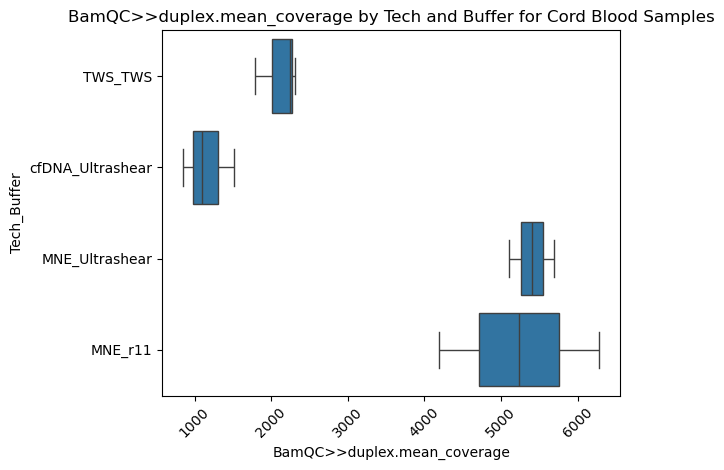

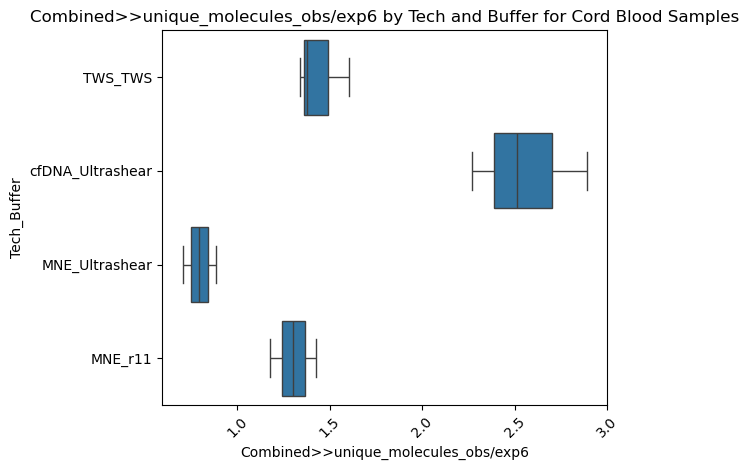

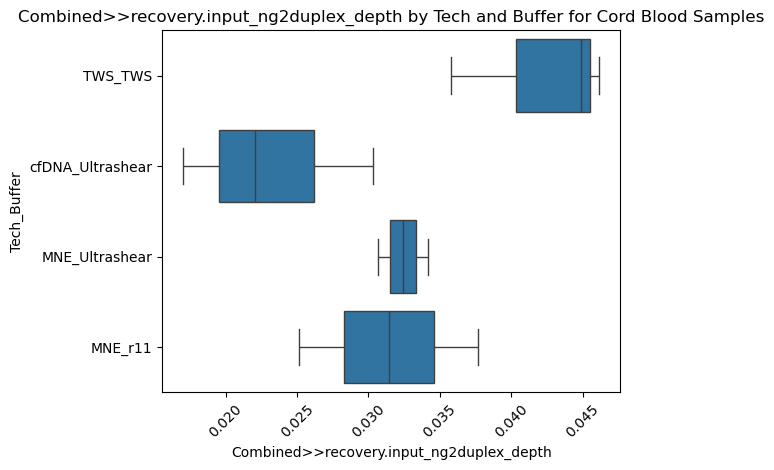

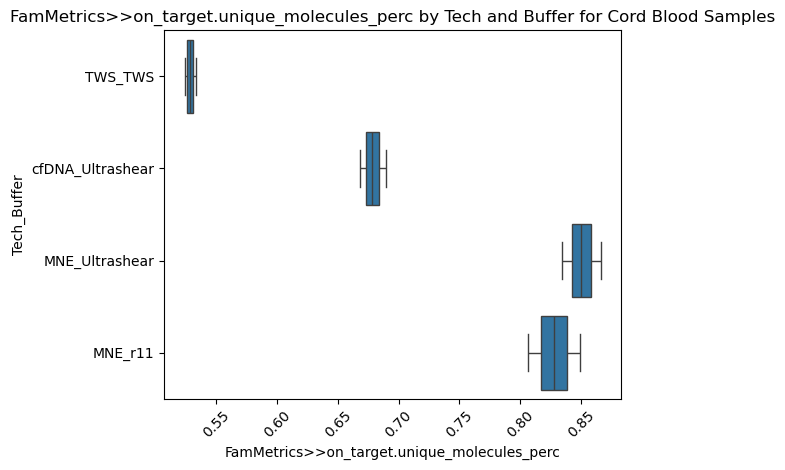

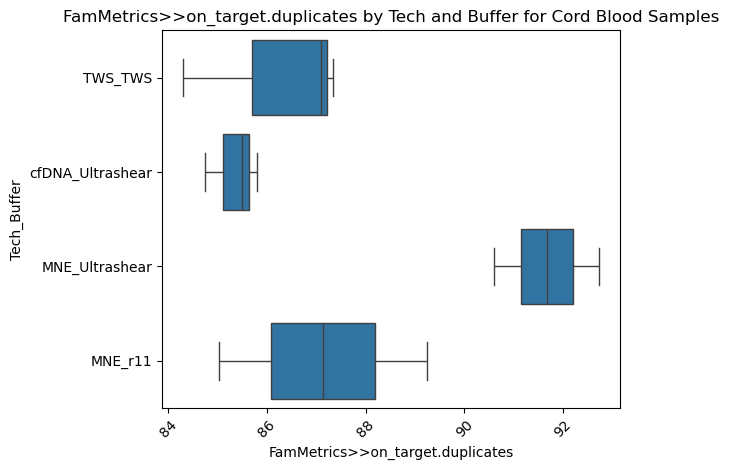

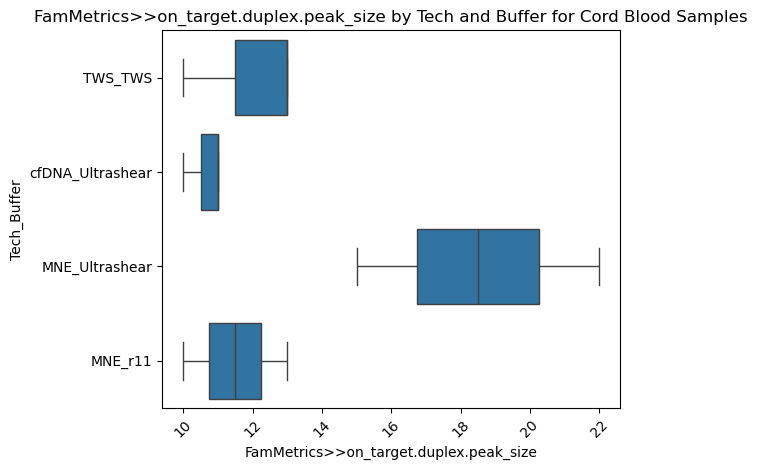

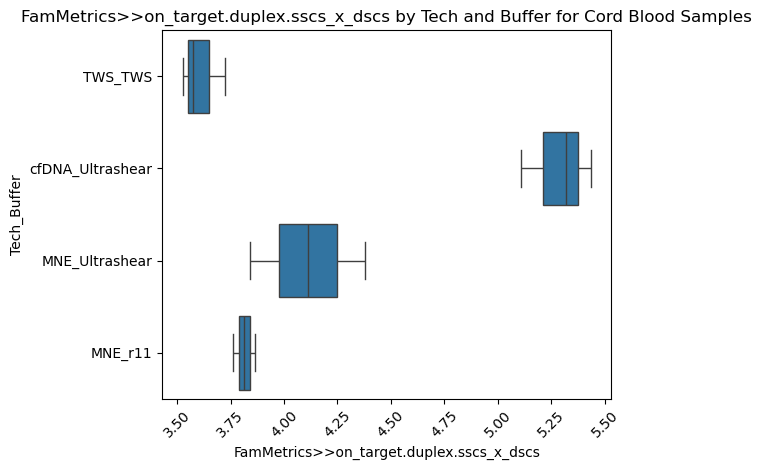

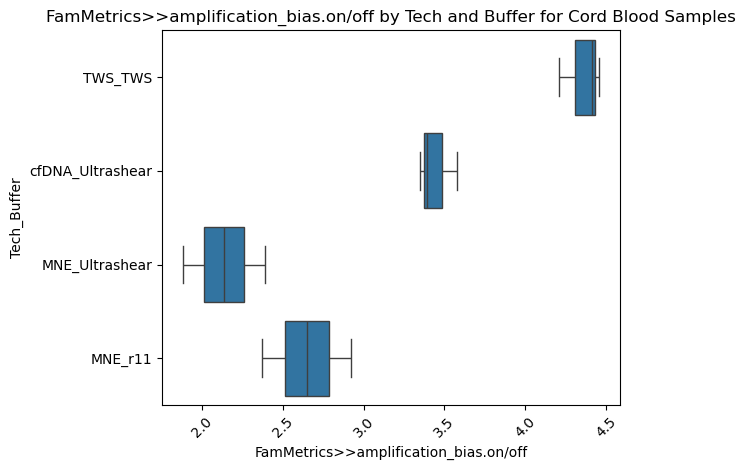

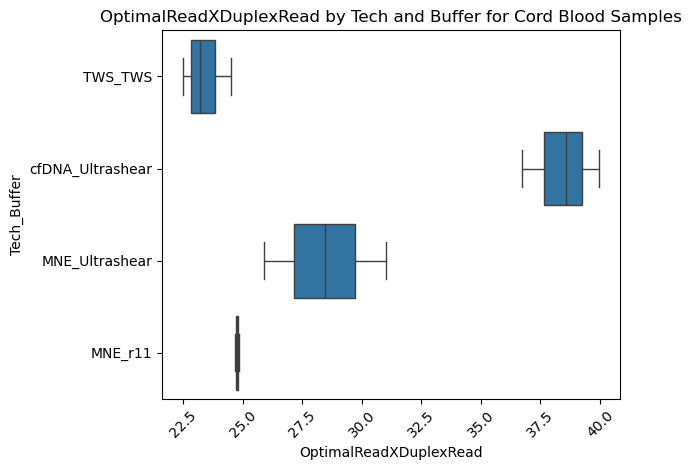

In [10]:
for columnnnn in columns_to_plot:
    sns.boxplot(data = cord_blood_data,
            x = columnnnn,
            y = "tech_buffer")
    plt.xlabel(columnnnn)
    plt.ylabel("Tech_Buffer")
    plt.title(f"{columnnnn} by Tech and Buffer for Cord Blood Samples")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
                

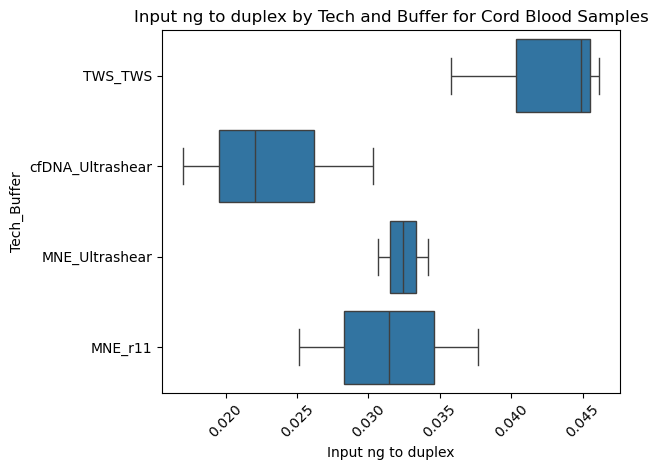

In [ ]:
sns.boxplot(data = cord_blood_data,
            x = "Combined>>recovery.input_ng2duplex_depth",
            y = "tech_buffer")
plt.xlabel("Input ng to duplex")
plt.ylabel("Tech_Buffer")
plt.title("Input ng to duplex by Tech and Buffer for Cord Blood Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
            

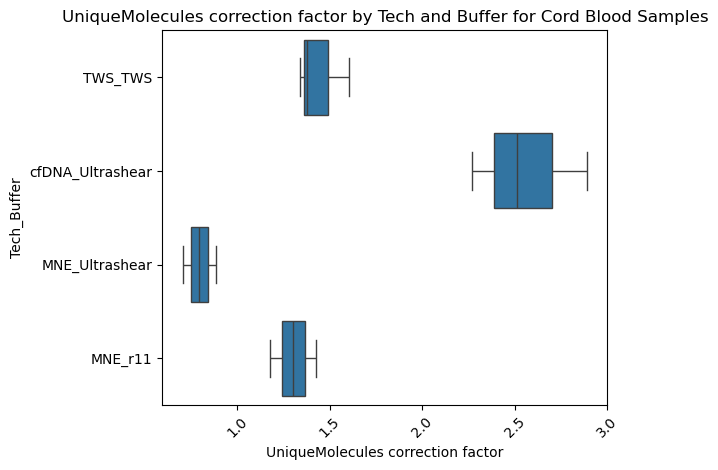

In [16]:
sns.boxplot(data = cord_blood_data,
            x = "Combined>>unique_molecules_obs/exp6",
            y = "tech_buffer")
plt.xlabel("UniqueMolecules correction factor")
plt.ylabel("Tech_Buffer")
plt.title("UniqueMolecules correction factor by Tech and Buffer for Cord Blood Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
            

In [ ]:
print(list(data.columns))
['PROJECT', 'Sample ID', 'IRB_subsample_id', 'WetLab>>Sample type', 'WetLab>>Panel', 'WetLab>>Panel Size (Kb)', 'WetLab>>Kit',
'WetLab>>Quantification gDNA --> Qubit conc. (ng/ul)', 'WetLab>>DNA integrity --> DIN', 'WetLab>>Input (ng)',
'WetLab>>Quantification (after fragmentation) --> DNA amount (ng)', 'WetLab>>TapeStation (after fragmentation) --> Size (bp)', 'WetLab>>Quantification (after ligation) --> DNA amount (ng)', 'WetLab>>TapeStation (after ligation) --> Size (bp)', 'WetLab>>qPCR --> Unique DNA amount (fmol)', 'WetLab>>Real diversity --> fmol to PCR1', 'WetLab>>Quantification POST-PCR1 --> DNA amount (ng)', 'WetLab>>Real input to capture --> DNA amount (ng)', 'WetLab>>TapeStation after PCR1 --> Size (bp)', 'WetLab>>Quantification POST-PCR2 --> Qubit conc. (ng/ul)', 'WetLab>>Quantification POST-PCR2 --> DNA amount (ng)', 'WetLab>>TapeStation after PCR2 --> Size (bp)', 'WetLab>>Quantification POST-PCR3 --> Qubit conc. (ng/ul)', 'WetLab>>Quantification POST-PCR3 --> DNA amount (ng)', 'WetLab>>BioAnalyzer / TS --> Peak (bp)', 'WetLab>>Molarity', 'WetLab>>Library prep', 'WetLab>>CNAG/Novogene barcode', 'WetLab>>Multiplexing', 'WetLab>>IRB_subsample_id', 'WetLab>>Notes', 'WetLab>>Multiplexing_binary', 'WetLab>>NUM_CAPTURES', 'WetLab>>SPLIT_PCR', 'WetLab>>SUBSET_DIVERSITY', 'WetLab>>Sequenced', 'WetLab>>Library_size (bp)', 'WetLab>>Ligation nonadapter size (bp)', 'WetLab>>Library nonadapter size (bp)', 'WetLab>>Recovery_Input2Lig_raw', 'WetLab>>Lig_genomic_DNA', 'WetLab>>Recovery_Input2Lig_genomic', 'WetLab>>qPCR unique molecules', 'WetLab>>Lig_qpcr_DNA', 'WetLab>>Recovery_Input2Lig_qpcr', 'WetLab>>TapeStation_PCR1-Ligation', 'WetLab>>Effective_bp_per_molecule-lig', 'WetLab>>Effective_bp_per_molecule-lib', 'WetLab>>Theoretical_max_depth-lig', 'WetLab>>Theoretical_max_depth-lib', 'SAMPLE_ID', 'ANALYSIS_BATCH', 'TISSUE', 'PATH', 'FamMetrics>>all.raw_reads', 'FamMetrics>>all.sscs', 'FamMetrics>>all.raw_x_sscs', 'FamMetrics>>all.duplicates', 'FamMetrics>>all.allm.dscs', 'FamMetrics>>all.duplex.dscs', 'FamMetrics>>all.allm.duplex_raw_reads', 'FamMetrics>>all.duplex.duplex_raw_reads', 'FamMetrics>>all.allm.duplex_raw_x_dscs', 'FamMetrics>>all.duplex.duplex_raw_x_dscs', 'FamMetrics>>all.allm.duplex_raw_x_sscs', 'FamMetrics>>all.duplex.duplex_raw_x_sscs', 'FamMetrics>>all.allm.duplex_sscs', 'FamMetrics>>all.duplex.duplex_sscs', 'FamMetrics>>all.allm.expected_dscs', 'FamMetrics>>all.duplex.expected_dscs', 'FamMetrics>>all.allm.noduplex_raw_reads', 'FamMetrics>>all.duplex.noduplex_raw_reads', 'FamMetrics>>all.allm.noduplex_raw_x_sscs', 'FamMetrics>>all.duplex.noduplex_raw_x_sscs', 'FamMetrics>>all.allm.noduplex_sscs', 'FamMetrics>>all.duplex.noduplex_sscs', 'FamMetrics>>all.allm.peak_size', 'FamMetrics>>all.duplex.peak_size', 'FamMetrics>>all.allm.quality_threshold', 'FamMetrics>>all.duplex.quality_threshold', 'FamMetrics>>all.allm.raw_x_dscs', 'FamMetrics>>all.duplex.raw_x_dscs', 'FamMetrics>>all.allm.recovery_of_dscs', 'FamMetrics>>all.duplex.recovery_of_dscs', 'FamMetrics>>all.allm.sscs_x_dscs', 'FamMetrics>>all.duplex.sscs_x_dscs', 'FamMetrics>>all.allm.uq_reads_duplex', 'FamMetrics>>all.duplex.uq_reads_duplex', 'FamMetrics>>all.unique_molecules', 'FamMetrics>>all.unique_reads', 'FamCurves>>all.allm.False.sscs', 'FamCurves>>all.allm.True.sscs', 'FamCurves>>all.duplex.False.sscs', 'FamCurves>>all.duplex.True.sscs', 'FamCurves>>all.dist.sscs', 'FamMetrics>>on_target.raw_reads', 'FamMetrics>>on_target.sscs', 'FamMetrics>>on_target.raw_x_sscs', 'FamMetrics>>on_target.duplicates', 'FamMetrics>>on_target.allm.dscs', 'FamMetrics>>on_target.duplex.dscs', 'FamMetrics>>on_target.allm.duplex_raw_reads', 'FamMetrics>>on_target.duplex.duplex_raw_reads', 'FamMetrics>>on_target.allm.duplex_raw_x_dscs', 'FamMetrics>>on_target.duplex.duplex_raw_x_dscs', 'FamMetrics>>on_target.allm.duplex_raw_x_sscs', 'FamMetrics>>on_target.duplex.duplex_raw_x_sscs', 'FamMetrics>>on_target.allm.duplex_sscs', 'FamMetrics>>on_target.duplex.duplex_sscs', 'FamMetrics>>on_target.allm.expected_dscs', 'FamMetrics>>on_target.duplex.expected_dscs', 'FamMetrics>>on_target.allm.noduplex_raw_reads', 'FamMetrics>>on_target.duplex.noduplex_raw_reads', 'FamMetrics>>on_target.allm.noduplex_raw_x_sscs', 'FamMetrics>>on_target.duplex.noduplex_raw_x_sscs', 'FamMetrics>>on_target.allm.noduplex_sscs', 'FamMetrics>>on_target.duplex.noduplex_sscs', 'FamMetrics>>on_target.allm.peak_size', 'FamMetrics>>on_target.duplex.peak_size', 'FamMetrics>>on_target.allm.quality_threshold', 'FamMetrics>>on_target.duplex.quality_threshold', 'FamMetrics>>on_target.allm.raw_x_dscs', 'FamMetrics>>on_target.duplex.raw_x_dscs', 'FamMetrics>>on_target.allm.recovery_of_dscs', 'FamMetrics>>on_target.duplex.recovery_of_dscs', 'FamMetrics>>on_target.allm.sscs_x_dscs', 'FamMetrics>>on_target.duplex.sscs_x_dscs', 'FamMetrics>>on_target.allm.uq_reads_duplex', 'FamMetrics>>on_target.duplex.uq_reads_duplex', 'FamMetrics>>on_target.unique_molecules', 'FamMetrics>>on_target.unique_reads', 'FamCurves>>on_target.allm.False.sscs', 'FamCurves>>on_target.allm.True.sscs', 'FamCurves>>on_target.duplex.False.sscs', 'FamCurves>>on_target.duplex.True.sscs', 'FamCurves>>on_target.dist.sscs', 'FamMetrics>>off_target.sscs', 'FamMetrics>>off_target.raw_reads', 'FamMetrics>>off_target.unique_molecules', 'FamMetrics>>off_target.unique_reads', 'FamMetrics>>off_target.raw_x_sscs', 'FamMetrics>>off_target.allm.dscs', 'FamMetrics>>off_target.allm.raw_x_dscs', 'FamMetrics>>off_target.allm.sscs_x_dscs', 'FamMetrics>>off_target.duplex.dscs', 'FamMetrics>>off_target.duplex.raw_x_dscs', 'FamMetrics>>off_target.duplex.sscs_x_dscs', 'FamCurves>>off_target.dist.sscs', 'FamCurves>>off_target.allm.False.sscs', 'FamCurves>>off_target.allm.True.sscs', 'FamCurves>>off_target.duplex.False.sscs', 'FamCurves>>off_target.duplex.True.sscs', 'FamMetrics>>on_target.unique_molecules_perc', 'FamMetrics>>off_target.unique_molecules_perc', 'FamMetrics>>amplification_bias.on/off', 'FamMetrics>>molecules_for_optimal_on_target', 'FamMetrics>>molecules_for_optimal_off_target', 'FamMetrics>>total_molecules_for_optimal', 'FamMetrics>>total_GBs_for_optimal', 'BamQC>>raw.total_reads', 'BamQC>>raw.mapped_reads', 'BamQC>>raw.general_error_rate', 'BamQC>>raw.mean_coverage', 'BamQC>>raw.regions_size', 'BamQC>>raw.regions_mapped_reads', 'BamQC>>raw.percentage_aligned', 'BamQC>>raw.percentage_aligned_on_target', 'BamQC>>raw.median_coverage', 'BamQC>>raw.median_insert_size', 'BamQC>>am.total_reads', 'BamQC>>am.mapped_reads', 'BamQC>>am.general_error_rate', 'BamQC>>am.mean_coverage', 'BamQC>>am.regions_size', 'BamQC>>am.regions_mapped_reads', 'BamQC>>am.percentage_aligned', 'BamQC>>am.percentage_aligned_on_target', 'BamQC>>am.median_coverage', 'BamQC>>am.median_insert_size', 'BamQC>>duplex.total_reads', 'BamQC>>duplex.mapped_reads', 'BamQC>>duplex.general_error_rate', 'BamQC>>duplex.mean_coverage', 'BamQC>>duplex.regions_size', 'BamQC>>duplex.regions_mapped_reads', 'BamQC>>duplex.percentage_aligned', 'BamQC>>duplex.percentage_aligned_on_target', 'BamQC>>duplex.median_coverage', 'BamQC>>duplex.median_insert_size', 'FastQC>>total_sequences', 'FastQC>>percent_duplicates', 'FastQC>>percent_gc', 'SeqInfo>>GBs_obtained', 'SeqInfo>>GBs_missing', 'DryLab>>SEQUENCING_PANEL', 'DryLab>>PANEL2GENOMEratio', 'DryLab>>on_target.duplex.efficiency', 'DATE_added', 'BamQC>>raw.plot.insert_size.data', 'BamQC>>raw.plot.insert_size.sizes', 'BamQC>>raw.plot.insert_size.values', 'BamQC>>am.plot.insert_size.data', 'BamQC>>am.plot.insert_size.sizes', 'BamQC>>am.plot.insert_size.values', 'BamQC>>duplex.plot.insert_size.data', 'BamQC>>duplex.plot.insert_size.sizes', 'BamQC>>duplex.plot.insert_size.values', 'Combined>>PANEL_n_CAPTURES', 'WetLab>>P2G_ratio_from_wetlab_name', 'WetLab>>qpcr_unique_molecules_1', 'WetLab>>qpcr_unique_molecules_6', 'Combined>>unique_molecules_obs/exp1', 'Combined>>unique_molecules_obs/exp6',
'Combined>>recovery.input_ng2duplex_depth', 'Combined>>recovery.lig_ng2duplex_depth', 'Combined>>recovery.qpcr_ng2duplex_depth', 'Novogene>>Sample_barcode',
'Novogene>>Project_ID', 'Novogene>>GBs_obtained', 'Novogene>>GBs_requested', 'SeqInfo>>GBs_not_analysed', 'Combined>>GBs_requested/optimal']


['PROJECT', 'Sample ID', 'IRB_subsample_id', 'WetLab>>Sample type', 'WetLab>>Panel', 'WetLab>>Panel Size (Kb)', 'WetLab>>Kit', 'WetLab>>Quantification gDNA --> Qubit conc. (ng/ul)', 'WetLab>>DNA integrity --> DIN', 'WetLab>>Input (ng)', 'WetLab>>Quantification (after fragmentation) --> DNA amount (ng)', 'WetLab>>TapeStation (after fragmentation) --> Size (bp)', 'WetLab>>Quantification (after ligation) --> DNA amount (ng)', 'WetLab>>TapeStation (after ligation) --> Size (bp)', 'WetLab>>qPCR --> Unique DNA amount (fmol)', 'WetLab>>Real diversity --> fmol to PCR1', 'WetLab>>Quantification POST-PCR1 --> DNA amount (ng)', 'WetLab>>Real input to capture --> DNA amount (ng)', 'WetLab>>TapeStation after PCR1 --> Size (bp)', 'WetLab>>Quantification POST-PCR2 --> Qubit conc. (ng/ul)', 'WetLab>>Quantification POST-PCR2 --> DNA amount (ng)', 'WetLab>>TapeStation after PCR2 --> Size (bp)', 'WetLab>>Quantification POST-PCR3 --> Qubit conc. (ng/ul)', 'WetLab>>Quantification POST-PCR3 --> DNA amount (

In [ ]:
SeqInfo>>GBs_not_analysed

In [7]:
# [x for x in data.columns if "percentage_aligned_on_target" in x]
[x for x in data.columns if "GB" in x]

['FamMetrics>>total_GBs_for_optimal',
 'SeqInfo>>GBs_obtained',
 'SeqInfo>>GBs_missing',
 'Novogene>>GBs_obtained',
 'Novogene>>GBs_requested',
 'SeqInfo>>GBs_not_analysed',
 'Combined>>GBs_requested/optimal']

In [8]:
cord_blood_data[['SAMPLE_ID', 'FamMetrics>>total_GBs_for_optimal',
 'SeqInfo>>GBs_obtained',
 'SeqInfo>>GBs_missing',
 'Novogene>>GBs_obtained',
 'Novogene>>GBs_requested',
 'SeqInfo>>GBs_not_analysed',
 'Combined>>GBs_requested/optimal']]

,SAMPLE_ID,FamMetrics>>total_GBs_for_optimal,SeqInfo>>GBs_obtained,SeqInfo>>GBs_missing,Novogene>>GBs_obtained,Novogene>>GBs_requested,SeqInfo>>GBs_not_analysed,Combined>>GBs_requested/optimal
0,SC001_B1_1_H_1,171.525940,240.594408,69.068468,240.59,250.0,-0.004408,1.457505
1,SC001_B1_1_H_2,125.395198,125.644709,0.249512,125.64,124.0,-0.004709,0.988874
2,SC001_B1_2_H_1,532.287160,1176.430771,644.143611,1176.43,1000.0,-0.000771,1.878685
3,SC001_B1_2_H_2,370.255358,416.093556,45.838197,416.09,405.0,-0.003556,1.093840
4,SC002_B1_1_H_1,213.102536,296.975220,83.872684,296.98,302.0,0.004780,1.417158
5,SC002_B1_1_H_2,157.423459,164.706494,7.283035,164.71,160.0,0.003506,1.016367
6,SC003_B1_1_H_1,227.476337,257.551613,30.075276,257.55,274.0,-0.001613,1.204521
7,SC003_B1_1_H_2,206.335364,223.230757,16.895393,223.24,226.0,0.009243,1.095304
8,SC003_B1_2_H_1,543.873055,886.004686,342.131630,886.01,845.0,0.005314,1.553671
9,SC003_B1_2_H_2,554.848879,832.421505,277.572626,832.43,750.0,0.008495,1.351719


## ON TARGET percentages

In [15]:
subset_data = data[['PROJECT', 'Sample ID', 'BamQC>>raw.percentage_aligned_on_target','ANALYSIS_BATCH',
                    'BamQC>>am.percentage_aligned_on_target',
                    'BamQC>>duplex.percentage_aligned_on_target',
                    'FamMetrics>>on_target.unique_molecules_perc'
                    ]].copy()
subset_data['FamMetrics>>on_target'] = subset_data['FamMetrics>>on_target.unique_molecules_perc'] * 100
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['BamQC>>raw.percentage_aligned_on_target',
                                                                                'BamQC>>am.percentage_aligned_on_target',
                                                                                'BamQC>>duplex.percentage_aligned_on_target',
                                                                                'FamMetrics>>on_target'
                                                                                ]].mean()

,BamQC>>raw.percentage_aligned_on_target,BamQC>>am.percentage_aligned_on_target,BamQC>>duplex.percentage_aligned_on_target,FamMetrics>>on_target
PROJECT,,,,
IDT004,83.235528,65.922771,95.893145,65.675941
IDT006,81.463189,62.268431,94.567056,60.769887
IDT007,81.953577,82.161230,94.693844,81.421115
IDT009,82.745729,74.639011,95.788956,64.868256
IDT012,84.134587,80.992156,96.436432,73.894479
IDT013,84.222041,83.692852,96.550905,76.565385
IDT014,84.349428,83.708236,97.144143,73.967904
IDT015,79.932817,71.627818,97.095087,61.196323
IDT016,87.153781,85.684991,97.502937,79.505054


In [16]:
sorted(subset_data["PROJECT"].unique())

['IDT004',
 'IDT006',
 'IDT007',
 'IDT009',
 'IDT012',
 'IDT013',
 'IDT014',
 'IDT015',
 'IDT016',
 'IDT017',
 'IDT018',
 'IDT019',
 'IDT020',
 'IDT021',
 'IDT022',
 'IDT023',
 'IDT026',
 'IDT027',
 'LOPEBIG_46',
 'MNE05',
 'MNE09',
 'PROMINENT_03',
 'PROMINENT_05',
 'PROMINENT_08-1',
 'PROMINENT_08-2',
 'PROMINENT_08-3',
 'PROMINENT_09',
 'PROMINENT_10',
 'PROMINENT_11',
 'PROMINENT_12',
 'TWS002',
 'TWS004',
 'TWS005',
 'TWS006',
 'TWS007',
 'TWS008',
 'TWS009',
 'TWS010',
 'TWS011',
 'TWS012',
 'TWS013',
 'TWS014',
 'TWS015',
 'TWS016',
 'TWS017',
 'TWS018',
 'TWS019',
 'TWS020',
 'TWS021',
 'TWS022',
 'TWS023',
 'TWS024',
 'TWS025',
 'TWS026',
 'TWS027',
 'TWS028',
 'TWS029',
 'TWS030',
 'TWS032',
 'TWS033',
 'TWS034',
 'TWS035',
 'TWS036',
 'TWS037',
 'TWS038',
 'TWS039',
 'TWS040',
 'TWS041',
 'TWS042',
 'TWS043',
 'TWS044',
 'TWS045',
 'TWS046',
 'TWS047',
 'TWS048',
 'TWS049',
 'TWS050']

/tmp/ipykernel_1004888/4207125556.py:43: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


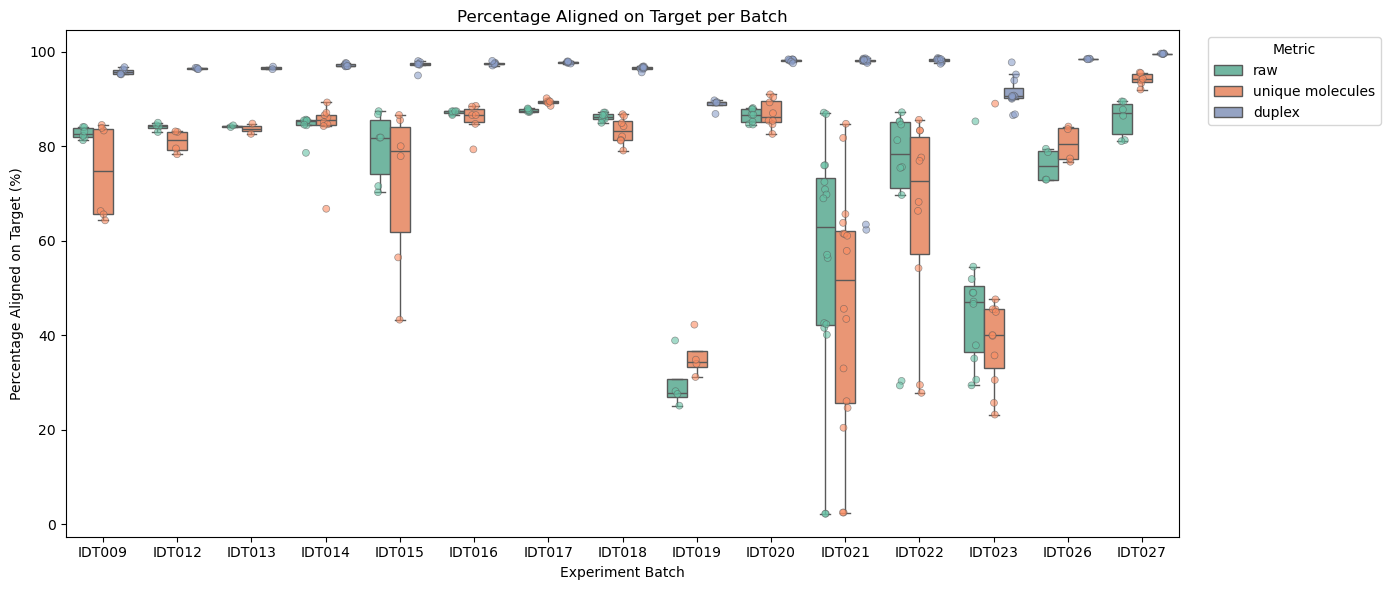

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# your variables of interest
to_plot = [
    'BamQC>>raw.percentage_aligned_on_target',
    'BamQC>>am.percentage_aligned_on_target',
    'BamQC>>duplex.percentage_aligned_on_target',
    # 'FamMetrics>>on_target'
]

# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([#'IDT004', 'IDT006', 'IDT007',
                             'IDT009', 'IDT012', 'IDT013', 'IDT014', 'IDT015',
                             'IDT016', 'IDT017', 'IDT018', 'IDT019', 'IDT020',
                             'IDT021', 'IDT022', 'IDT023', 'IDT026', 'IDT027',
                             ])].copy()
df = df.sort_values(by = "PROJECT").reset_index(drop=True)

# reshape from wide to long format
long_df = df.melt(
    id_vars="PROJECT",
    value_vars=to_plot,
    var_name="Metric",
    value_name="Percentage_on_target"
)

# rename Metric column for nicer display
long_df["Metric"] = long_df["Metric"].str.replace("BamQC>>", "").str.replace(".percentage_aligned_on_target", "").str.replace("am", "unique molecules")

# set up plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=long_df,
    x="PROJECT",
    y="Percentage_on_target",
    hue="Metric",
    palette="Set2",
    showfliers=False
)
sns.stripplot(
    data=long_df,
    x="PROJECT",
    y="Percentage_on_target",
    hue="Metric",
    dodge=True,
    alpha=0.6,
    palette="Set2",
    linewidth=0.5,
    edgecolor="gray",
    legend=False
)

# tidy up
plt.title("Percentage Aligned on Target per Batch")
plt.ylabel("Percentage Aligned on Target (%)")
plt.xlabel("Experiment Batch")
# plt.xticks(range(len(df["PROJECT"].unique())), [f"Exp_{i}" for i in range(len(df["PROJECT"].unique()))])
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## PICARD Mean Insert size

In [8]:
[x for x in data.columns if "insert" in x]

['BamQC>>raw.median_insert_size',
 'BamQC>>am.median_insert_size',
 'BamQC>>duplex.median_insert_size',
 'BamQC>>raw.plot.insert_size.data',
 'BamQC>>raw.plot.insert_size.sizes',
 'BamQC>>raw.plot.insert_size.values',
 'BamQC>>am.plot.insert_size.data',
 'BamQC>>am.plot.insert_size.sizes',
 'BamQC>>am.plot.insert_size.values',
 'BamQC>>duplex.plot.insert_size.data',
 'BamQC>>duplex.plot.insert_size.sizes',
 'BamQC>>duplex.plot.insert_size.values']

In [9]:
subset_data = data[['PROJECT', 'Sample ID','BamQC>>raw.median_insert_size',
                    ]].copy()
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['BamQC>>raw.median_insert_size']].mean()

,BamQC>>raw.median_insert_size
PROJECT,
IDT004,334.500000
IDT006,323.500000
IDT007,477.500000
IDT009,298.583333
IDT012,278.750000
IDT013,290.000000
IDT014,271.250000
IDT015,277.166667
IDT016,292.000000


## PICARD Mean coverage

In [14]:
[x for x in data.columns if "mean_coverage" in x]

['BamQC>>raw.mean_coverage',
 'BamQC>>am.mean_coverage',
 'BamQC>>duplex.mean_coverage']

In [15]:
subset_data = data[['PROJECT', 'Sample ID', 'BamQC>>raw.mean_coverage','BamQC>>am.mean_coverage',
 'BamQC>>duplex.mean_coverage'
                    ]].copy()
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['BamQC>>raw.mean_coverage',
                                                                                'BamQC>>am.mean_coverage',
                                                                                'BamQC>>duplex.mean_coverage']].mean()

,BamQC>>raw.mean_coverage,BamQC>>am.mean_coverage,BamQC>>duplex.mean_coverage
PROJECT,,,
IDT004,87785.320150,5450.655800,1293.215350
IDT006,71023.757700,5132.587350,1375.956500
IDT007,85391.516400,9709.570600,2180.159700
IDT009,16754.109642,3613.205267,758.107717
IDT012,99650.463188,9638.980725,2431.861700
IDT013,88138.961700,5995.304650,1314.257600
IDT014,74281.053662,6155.528375,1433.416637
IDT015,71419.687183,5172.294500,1276.992700
IDT016,99203.464850,5988.233867,1374.070050


## PICARD percent duplication

In [17]:
[x for x in data.columns if "duplicat" in x]

['FamMetrics>>all.duplicates',
 'FamMetrics>>on_target.duplicates',
 'FastQC>>percent_duplicates']

In [18]:
subset_data = data[['PROJECT', 'Sample ID', 'FamMetrics>>all.duplicates',
                        'FamMetrics>>on_target.duplicates',
                        'FastQC>>percent_duplicates'
                    ]].copy()
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['FamMetrics>>all.duplicates',
                                                                                'FamMetrics>>on_target.duplicates',
                                                                                'FastQC>>percent_duplicates']].mean()

,FamMetrics>>all.duplicates,FamMetrics>>on_target.duplicates,FastQC>>percent_duplicates
PROJECT,,,
IDT004,88.258790,90.688117,81.835771
IDT006,85.604455,89.007703,85.330218
IDT007,85.606558,86.712647,71.799585
IDT009,82.498192,86.059859,70.287833
IDT012,91.124021,92.271994,87.696250
IDT013,88.028645,89.340120,89.492909
IDT014,85.014496,86.610405,87.297571
IDT015,84.037240,88.041682,84.790913
IDT016,89.088259,90.514773,87.977488


## GC content

In [9]:
[x for x in data.columns if "gc" in x]

['FastQC>>percent_gc']

In [10]:
subset_data = data[['PROJECT', 'Sample ID','FastQC>>percent_gc',
                    ]].copy()
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['FastQC>>percent_gc']].mean()

,FastQC>>percent_gc
PROJECT,
IDT004,47.250000
IDT006,48.000000
IDT007,48.000000
IDT009,46.583333
IDT012,48.625000
IDT013,48.500000
IDT014,48.812500
IDT015,48.250000
IDT016,48.666667
